### Overall Recommender App Run

- Import maps

In [1]:
import rasterio
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show
import pandas as pd

In [4]:
os.chdir("../")
dir = str(os.getcwd())
k_map = rasterio.open(os.path.join(dir, "static", "images", "k_map.tif"))
mg_map = rasterio.open(os.path.join(dir, "static", "images", "mg_map.tif"))
print(k_map.crs)
print(mg_map.crs)
print(k_map.bounds)
print(mg_map.bounds)

EPSG:4326
EPSG:4326
BoundingBox(left=37.218504815043794, bottom=-0.9570082603032498, right=38.34305481504379, top=0.11051173969675021)
BoundingBox(left=37.218504815043794, bottom=-0.9570082603032498, right=38.34305481504379, top=0.11051173969675021)


- Read ExK and ExMg from sample coords

Generate points: 
```
QGIS version: 3.34.3-Prizren
QGIS code revision: 47373234ac
Qt version: 5.15.3
Python version: 3.9.18
GDAL version: 3.8.3
GEOS version: 3.12.1-CAPI-1.18.1
PROJ version: Rel. 9.3.1, December 1st, 2023
PDAL version: 2.6.0 (git-version: 3fced5)
Algorithm started at: 2024-03-30T16:29:46
Algorithm 'Random points inside polygons' starting…
Input parameters:
{ 'INPUT' : 'D:/r/KenyaDSM/data/soil/ke_sp/soil_region.shp', 'MIN_DISTANCE' : None, 'OUTPUT' : 'D:/r/KenyaDSM/data/soil/ke_sp/sample/validation_pts.shp', 'STRATEGY' : 0, 'VALUE' : 20 }

Execution completed in 0.05 seconds
Results:
{'OUTPUT': 'D:/r/KenyaDSM/data/soil/ke_sp/sample/validation_pts.shp'}

Loading resulting layers
Algorithm 'Random points inside polygons' finished
```

<Axes: >

c:\Users\vikir\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\image.py:499: RuntimeWarning: overflow encountered in divide
  A_scaled /= ((a_max - a_min) / frac)


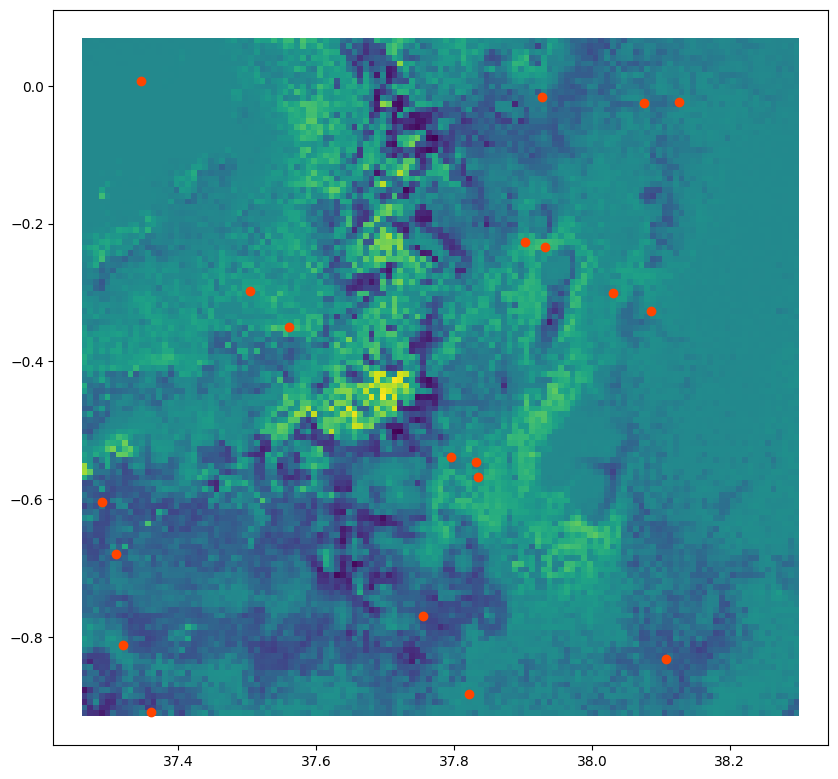

In [5]:
points = gpd.read_file("validation_pts.shp")
fig, ax = plt.subplots(figsize=(10,10))
points.plot(ax=ax, color="orangered")
show(k_map, ax=ax)

- retrieve and store available nutrients from points

In [6]:
# get available content from rasters: Potassium is more prevalent in veg.
conv_mg = 122
conv_k = 390

av_nutrients = []

web_y = -0.5042916989992321
web_x = 37.714691162109375

mg_row,mg_col = mg_map.index(web_x,web_y)
k_row, k_col = k_map.index(web_x,web_y)

print(mg_map.read(1)[mg_row, mg_col])
print(k_map.read(1)[k_row, k_col])

soil_mg = (mg_map.read(1)[mg_row, mg_col] * conv_mg)
soil_k = (k_map.read(1)[k_row, k_col] * conv_k)

av_nutrients.append({
    'Magnesium': round(soil_mg,2),
    'Potassium': round(soil_k,2)
})

# for point in points['geometry']:
#     x = point.xy[0][0]
#     y = point.xy[1][0]
  
#     mg_row,mg_col = mg_map.index(x,y)
#     k_row, k_col = k_map.index(x,y)

#     print(mg_map.read(1)[mg_row, mg_col])
#     print(k_map.read(1)[k_row, k_col])
    
#     soil_mg = (mg_map.read(1)[mg_row, mg_col] * conv_mg)
#     soil_k = (k_map.read(1)[k_row, k_col] * conv_k)

#     av_nutrients.append({
#         'Magnesium': round(soil_mg,2),
#         'Potassium': round(soil_k,2)
#     })
soil_nutrients = pd.DataFrame(av_nutrients)
soil_nutrients

2.0078673
0.27403462


,Magnesium,Potassium
0,244.96,106.87


- Predict category based on nutrients

In [7]:
# load model
import pickle as pkl

with open("k_dt.pkl", 'rb') as kf:
    k_mod = pkl.load(kf)
with open("mg_dt.pkl", 'rb') as mgf:
    mg_mod = pkl.load(mgf)

mg_cat = mg_mod.predict(pd.DataFrame(soil_nutrients.iloc[:,0]))
k_cat = k_mod.predict(pd.DataFrame(soil_nutrients.iloc[:,1]))
print(mg_cat)
print(k_cat)

['2']
['0']
